# Stock Movement Classification: Data, EDA & Visualization


---
### Setup & configuration

In [86]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
API_KEY    = os.environ["ALPACA_API_KEY"]
SECRET_KEY = os.environ["ALPACA_SECRET_KEY"]

SYMBOLS    = ["SPY", "NVDA", "MU", "TSLA"]
START, END = "2016-06-20", "2026-06-20"
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
N_CLASSES  = 5
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

print("Setup complete.")
print("  Symbols :", SYMBOLS)
print("  Range   :", START, "->", END)
print("  Split   : {:.0%} train / {:.0%} val / {:.0%} test".format(
    TRAIN_FRAC, VAL_FRAC, 1 - TRAIN_FRAC - VAL_FRAC))
print("  Keys loaded:", bool(API_KEY) and bool(SECRET_KEY))

Setup complete.
  Symbols : ['SPY', 'NVDA', 'MU', 'TSLA']
  Range   : 2016-06-20 -> 2026-06-20
  Split   : 70% train / 15% val / 15% test
  Keys loaded: True


---
### Data pull

I'm pulling daily bars from Alpaca. The one detail that really matters here is `Adjustment.ALL`. Without
it, NVDA's 10:1 and TSLA's 3:1 splits show up as 90% / 67% crashes and end up poisoning every return.

> I adopted this from Pallavi's pipeline so it stays comparable.

In [87]:
def download_prices(symbols, start, end, feed="iex"):
    from alpaca.data.historical import StockHistoricalDataClient
    from alpaca.data.requests import StockBarsRequest
    from alpaca.data.timeframe import TimeFrame
    from alpaca.data.enums import Adjustment, DataFeed

    client = StockHistoricalDataClient(API_KEY, SECRET_KEY)
    req = StockBarsRequest(
        symbol_or_symbols=list(symbols),
        timeframe=TimeFrame.Day,
        start=pd.Timestamp(start), end=pd.Timestamp(end),
        adjustment=Adjustment.ALL,                                  # split/dividend fix, else NVDA/TSLA splits look like crashes
        feed=DataFeed.SIP if feed.lower() == "sip" else DataFeed.IEX,
    )
    bars = client.get_stock_bars(req).df                            # comes back as a MultiIndex (symbol, timestamp)
    out = {}
    for s in symbols:
        d = bars.loc[s].copy()
        d.index = pd.DatetimeIndex(d.index).tz_localize(None)       # drop the tz, keep just the calendar date
        out[s] = d[["open", "high", "low", "close", "volume"]]
    return out

raw = download_prices(SYMBOLS, START, END, feed="iex")

# raw row count per symbol before any cleaning
rows_before = sum(len(raw[s]) for s in SYMBOLS)
for s in SYMBOLS:
    print(f"  {s:5s} {len(raw[s]):>5d} rows | {raw[s].index.min().date()} to {raw[s].index.max().date()}")
print("Total raw rows across all symbols:", rows_before)

  SPY    1483 rows | 2018-11-01 to 2026-06-18
  NVDA   1482 rows | 2020-07-27 to 2026-06-18
  MU     1482 rows | 2020-07-27 to 2026-06-18
  TSLA   1482 rows | 2020-07-27 to 2026-06-18
Total raw rows across all symbols: 5929


---
### Feature engineering

For every stock, the same feature set is built from its raw OHLCV bars, each one turning price and volume into a signal, grouped by what it captures:

- Returns & momentum: daily and log returns, short lags, and momentum over 10 to 200 days
- Trend: price-to-moving-average distances, the 50/200 cross, and ADX (trend strength)
- Oscillators: RSI, MACD, Bollinger
- Volatility & range: realized volatility, ATR, daily high-low range, overnight gap
- Volume & money flow: volume ratios, MFI, CMF


> I adopted this from Pallavi's pipeline so it stays comparable.

In [88]:
def add_features(df):
    # Work on one symbol at a time, sorted oldest to newest.
    df = df.sort_index().copy()
    close = df["close"]
    vol   = df["volume"]

    # daily returns (the core signal)
    df["ret_1"]   = close.pct_change()
    df["log_ret"] = np.log(close).diff()

    # yesterday / 2 days ago / 3 days ago returns (short-term memory)
    for lag in (1, 2, 3):
        df[f"ret_lag{lag}"] = df["ret_1"].shift(lag)

    # momentum over several horizons = return over the last k days
    # (this is the stationary stand-in for "lagged price")
    for k in (10, 20, 30, 50, 100, 200):
        df[f"mom_{k}"] = close / close.shift(k) - 1

    # moving averages: keep the raw MA for plotting, but feed the model the
    # distance from price to the MA (a ratio), which stays on the same scale across years
    for w in (10, 20, 50, 100, 200):
        ma = close.rolling(w).mean()
        df[f"ma_{w}"]         = ma
        df[f"price_to_ma{w}"] = close / ma - 1
    df["ma_cross"] = df["ma_50"] / df["ma_200"] - 1     # 50/200 crossover (golden vs death cross)

    # RSI (14, Wilder smoothing)
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

    # MACD (12/26 EMAs, 9-day signal). Divided by price so the scale is stable over 10 years.
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["macd"]        = (ema12 - ema26) / close
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    # Bollinger Bands turned into %b: where price sits inside the 20-day band (0 = bottom, 1 = top)
    mid   = close.rolling(20).mean()
    sd    = close.rolling(20).std()
    df["bb_pct"] = (close - (mid - 2 * sd)) / ((mid + 2 * sd) - (mid - 2 * sd))

    # realized volatility and how busy volume is vs its own average
    df["volatility_20"] = df["ret_1"].rolling(20).std()
    for w in (10, 20, 50):
        df[f"vol_ratio{w}"] = vol / vol.rolling(w).mean()

    # daily high-low range and the overnight gap (intraday swing plus the jump from prev close to open)
    high = df["high"]; low = df["low"]; openp = df["open"]
    prev_close = close.shift(1)
    df["range_hl"] = (high - low) / close
    df["gap"]      = (openp - prev_close) / prev_close

    # ATR (14): average true range as volatility, divided by price to keep it stationary
    tr = pd.concat([(high - low),
                    (high - prev_close).abs(),
                    (low  - prev_close).abs()], axis=1).max(axis=1)
    atr_raw = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["atr_14"] = atr_raw / close

    # ADX (14): how strong the trend is, pulled from the +DI / -DI directional movement
    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm  = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=df.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=df.index)
    plus_di  = 100 * plus_dm.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr_raw
    minus_di = 100 * minus_dm.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr_raw
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df["adx_14"] = dx.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    # MFI (14): basically RSI but weighted by volume
    typical    = (high + low + close) / 3
    money_flow = typical * vol
    pos_mf = money_flow.where(typical > typical.shift(1), 0.0).rolling(14).sum()
    neg_mf = money_flow.where(typical < typical.shift(1), 0.0).rolling(14).sum()
    df["mfi_14"] = 100 - 100 / (1 + pos_mf / neg_mf)

    # CMF (20): Chaikin Money Flow, money flowing in vs out over 20 days (volume-weighted)
    mfm = ((close - low) - (high - close)) / (high - low)   # money flow multiplier
    mfv = mfm * vol                                          # money flow volume
    df["cmf_20"] = mfv.rolling(20).sum() / vol.rolling(20).sum()

    # label source: NEXT day's return. Used ONLY to build the target, never as a feature.
    df["fwd_ret"] = close.pct_change().shift(-1)
    return df

# features fed to the model
FEATURE_COLS = (
    ["ret_1", "log_ret", "ret_lag1", "ret_lag2", "ret_lag3"]
    + [f"mom_{k}" for k in (10, 20, 30, 50, 100, 200)]
    + [f"price_to_ma{w}" for w in (10, 20, 50, 100, 200)]
    + ["ma_cross", "rsi_14", "macd", "macd_signal", "macd_hist", "bb_pct", "volatility_20"]
    + [f"vol_ratio{w}" for w in (10, 20, 50)]
    + ["atr_14", "adx_14", "mfi_14", "cmf_20", "range_hl", "gap"]
)

feat = {s: add_features(raw[s]) for s in SYMBOLS}
print(len(FEATURE_COLS), "features per symbol:")
print(FEATURE_COLS)

32 features per symbol:
['ret_1', 'log_ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'mom_10', 'mom_20', 'mom_30', 'mom_50', 'mom_100', 'mom_200', 'price_to_ma10', 'price_to_ma20', 'price_to_ma50', 'price_to_ma100', 'price_to_ma200', 'ma_cross', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_pct', 'volatility_20', 'vol_ratio10', 'vol_ratio20', 'vol_ratio50', 'atr_14', 'adx_14', 'mfi_14', 'cmf_20', 'range_hl', 'gap']


---
### Target & chronological split (shared setup)

This cell defines the 5-class quintile target and the chronological train/val/test split, matching the setup Pallavi and Neil used so the results line up across notebooks.

**Target:** 5 classes = quintiles of next-day return

    - 0 = 0-20%
    - 1 = 20%-40%
    - 2 = 40%-60%
    - 3 = 60%-80%
    - 4 = 80%-100%


In [89]:
# build the chronological split
all_dates = sorted(set().union(*[set(feat[s].index) for s in SYMBOLS]))
N = len(all_dates)
TRAIN_END = all_dates[int(N * TRAIN_FRAC)]
VAL_END   = all_dates[int(N * (TRAIN_FRAC + VAL_FRAC))]
print(f"train <= {TRAIN_END.date()} | val <= {VAL_END.date()} | test > {VAL_END.date()}\n")

def split_tag(idx):
    if idx <= TRAIN_END: return "train"
    if idx <= VAL_END:   return "val"
    return "test"

def fit_quantile_edges(train_fwd, n_classes=5):
    # fit the edges on train only so future returns don't leak
    qs = np.linspace(0, 1, n_classes + 1)[1:-1]
    return train_fwd.dropna().quantile(qs).tolist()

def apply_edges(fwd_ret, edges):
    # drop each return into its bucket, but keep NaN as NaN
    t = np.digitize(fwd_ret, edges).astype(float)
    t[np.isnan(fwd_ret)] = np.nan
    return t

# label the target per symbol
for s in SYMBOLS:
    df = feat[s]
    df["split"] = [split_tag(i) for i in df.index]
    edges = fit_quantile_edges(df.loc[df.split == "train", "fwd_ret"], N_CLASSES)
    df["target"] = apply_edges(df["fwd_ret"].values, edges)
    df.attrs["cuts"] = [round(e, 5) for e in edges]
    dist = df["target"].value_counts(normalize=True).sort_index().round(3).to_dict()
    print(f"  {s:5s} cuts={[round(e, 5) for e in edges]}  dist={dist}")

train <= 2024-09-10 | val <= 2025-07-31 | test > 2025-07-31

  SPY   cuts=[-0.00691, -0.00124, 0.00274, 0.00889]  dist={0.0: 0.184, 1.0: 0.204, 2.0: 0.205, 3.0: 0.229, 4.0: 0.178}
  NVDA  cuts=[-0.0211, -0.00495, 0.00904, 0.02581]  dist={0.0: 0.189, 1.0: 0.203, 2.0: 0.215, 3.0: 0.204, 4.0: 0.19}
  MU    cuts=[-0.01897, -0.00467, 0.00634, 0.01977]  dist={0.0: 0.216, 1.0: 0.181, 2.0: 0.182, 3.0: 0.174, 4.0: 0.248}
  TSLA  cuts=[-0.02569, -0.00573, 0.00819, 0.02907]  dist={0.0: 0.2, 1.0: 0.207, 2.0: 0.198, 3.0: 0.192, 4.0: 0.204}


---
### Preprocessing

  - Missing values: every row containing a NaN is dropped.
  - Outliers: kept, since they're real market moves and not data errors.
  - Scaling: features are standardized with StandardScaler, fit on the training data only.
  - Feature selection: returns and ratios, ranked by how they correlate with the target.
  - Encoding: nothing needed, since all inputs are already numeric.

In [90]:
from sklearn.preprocessing import StandardScaler

# stack all the symbols into one frame
full = pd.concat([feat[s].assign(symbol=s) for s in SYMBOLS])

# treat inf as missing (e.g. vol_ratio blows up when a rolling-volume window is 0) so it gets dropped too
full = full.replace([np.inf, -np.inf], np.nan)
rows_before_pp = len(full)

# print which columns drive the drop so it's not a black box
na_counts = full[FEATURE_COLS + ["target"]].isna().sum()
print("NaNs per column (only those with any):")
print(na_counts[na_counts > 0].sort_values(ascending=False).to_string(), "\n")

# drop the missing rows
full = full.dropna(subset=FEATURE_COLS + ["target"]).copy()
full["target"] = full["target"].astype(int)
rows_after_pp = len(full)
print(f"Rows before preprocessing: {rows_before_pp}")
print(f"Rows after preprocessing : {rows_after_pp}  (dropped {rows_before_pp - rows_after_pp} warmup/edge rows)\n")

def xy(split):
    d = full[full.split == split]
    return d[FEATURE_COLS], d["target"]

Xtr, ytr = xy("train")
Xva, yva = xy("val")
Xte, yte = xy("test")
for name, X in [("train", Xtr), ("val", Xva), ("test", Xte)]:
    d = full[full.split == name]
    print(f"  {name:5s}: {len(X):>5d} rows  ({d.index.min().date()} to {d.index.max().date()})")

# standardize: fit the scaler on train only, then reuse on val/test
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)
Xte_s = scaler.transform(Xte)
print(f"\nScaled. Train mean ~ {Xtr_s.mean():.4f}, std ~ {Xtr_s.std():.4f} (val/test use train's scaler).")

NaNs per column (only those with any):
mom_200           800
ma_cross          796
price_to_ma200    796
mom_100           400
price_to_ma100    396
mom_50            200
vol_ratio50       196
price_to_ma50     196
mom_30            120
adx_14            104
mom_20             80
volatility_20      80
cmf_20             77
vol_ratio20        76
price_to_ma20      76
bb_pct             76
rsi_14             56
atr_14             52
mfi_14             52
mom_10             40
vol_ratio10        36
price_to_ma10      36
ret_lag3           16
ret_lag2           12
ret_lag1            8
gap                 4
ret_1               4
log_ret             4
target              4 

Rows before preprocessing: 5929
Rows after preprocessing : 5125  (dropped 804 warmup/edge rows)

  train:  3353 rows  (2021-05-11 to 2024-09-10)
  val  :   888 rows  (2024-09-11 to 2025-07-31)
  test :   884 rows  (2025-08-01 to 2026-06-17)

Scaled. Train mean ~ -0.0000, std ~ 1.0000 (val/test use train's scaler).


I drop 804 rows here (5929 to 5125), and almost all of them come from mom_200, which is NaN for the first 200 rows of each stock while that window is still warming up.

---
### Exploratory data analysis

for this EDA, I explored these five things: 

1. return distributions
2. feature-target correlation + heatmap
3. RSI by class
4. feature importance
5. price & volatility over time

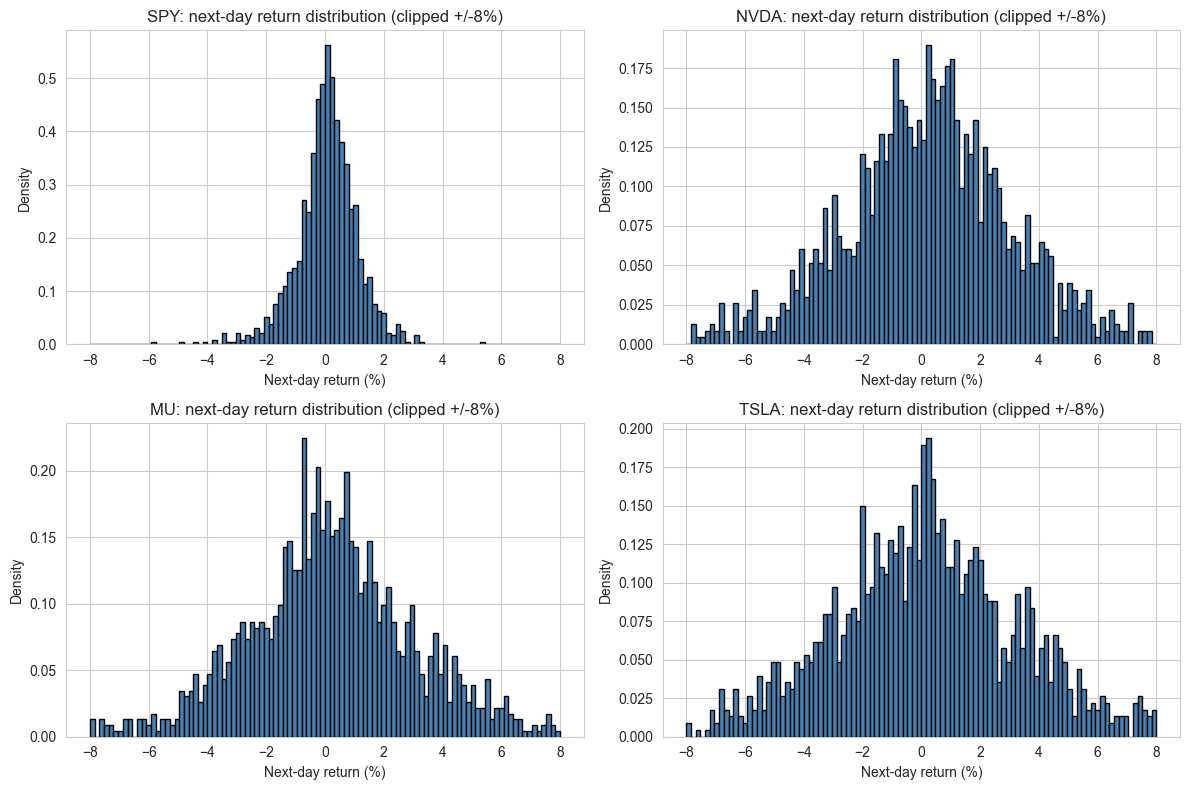

Symbol       Std %    Kurtosis
SPY          1.209       93.34
NVDA         3.191        4.34
MU           3.263        3.53
TSLA         3.833        3.33


In [91]:
# 1. next-day return distribution (one panel per stock)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, s in zip(axes.ravel(), SYMBOLS):
    r = feat[s]["fwd_ret"].dropna() * 100
    ax.hist(r, bins=100, range=(-8, 8), density=True, color="steelblue", edgecolor="black")
    ax.set_title(f"{s}: next-day return distribution (clipped +/-8%)")
    ax.set_xlabel("Next-day return (%)")
    ax.set_ylabel("Density")
plt.tight_layout(); plt.show()

# spread + kurtosis
print(f"{'Symbol':<8}{'Std %':>10}{'Kurtosis':>12}")
for s in SYMBOLS:
    r = feat[s]["fwd_ret"].dropna() * 100
    print(f"{s:<8}{r.std():>10.3f}{r.kurt():>12.2f}")

the individual stocks swing ~3x more than SPY (std ~3% vs ~1.2%), since SPY averages out as an index. but SPY has by far the fattest tails (kurtosis 93), so it barely moves most days, and the rare crash or spike really stands out.

Feature-to-target correlation (values near 0 = weak single-day signal):
                  SPY   NVDA     MU   TSLA
ret_1          -0.010 -0.020 -0.028 -0.035
log_ret        -0.009 -0.021 -0.028 -0.039
ret_lag1        0.021  0.028  0.015  0.022
ret_lag2       -0.007 -0.033  0.021 -0.004
ret_lag3       -0.030 -0.052 -0.027  0.014
mom_10         -0.008 -0.014 -0.038  0.030
mom_20         -0.008 -0.021  0.008  0.026
mom_30         -0.028 -0.034  0.006  0.017
mom_50         -0.037 -0.029  0.000 -0.020
mom_100        -0.015 -0.003  0.033 -0.026
mom_200         0.002 -0.015  0.034 -0.085
price_to_ma10  -0.027 -0.023 -0.024  0.009
price_to_ma20  -0.029 -0.027 -0.035  0.017
price_to_ma50  -0.028 -0.034 -0.005  0.012
price_to_ma100 -0.019 -0.019  0.009 -0.022
price_to_ma200 -0.006 -0.012  0.027 -0.049
ma_cross        0.011  0.002  0.039 -0.067
rsi_14         -0.026 -0.028 -0.025  0.028
macd           -0.003 -0.032 -0.009  0.010
macd_signal     0.001 -0.029  0.003  0.000
macd_hist      -0.011 -0.

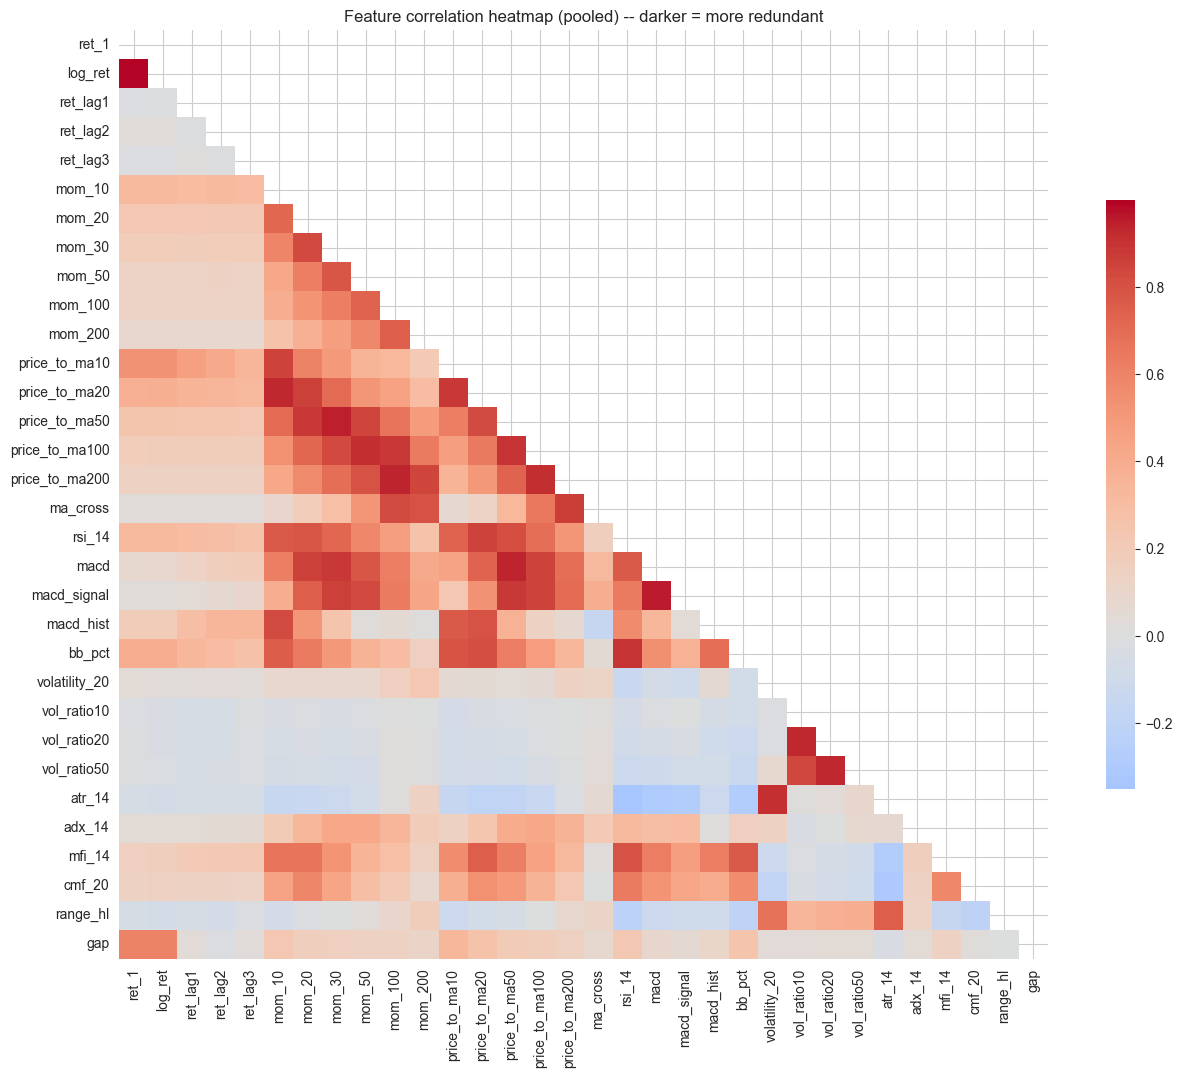

In [92]:
# 2. feature-target correlation
corr_tbl = pd.DataFrame({
    s: feat[s][FEATURE_COLS + ["target"]].corr()["target"].drop("target") for s in SYMBOLS
})
print("Feature-to-target correlation (values near 0 = weak single-day signal):")
print(corr_tbl.round(3).to_string())

# correlation heatmap
fig, ax = plt.subplots(figsize=(13, 11))
corr = full[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Feature correlation heatmap (pooled) -- darker = more redundant")
plt.tight_layout(); plt.show()

the heatmap basically tells me nothing predicts tomorrow on its own. Every value sits close to 0, so it's mostly noise, and the past indicators carry almost no edge on a one-day horizon.

/var/folders/b3/6y8qhvt56_z1swbjbctplhcc0000gn/T/ipykernel_6382/2570222187.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=["SD", "MD", "Flat", "MU", "SU"], showfliers=False)
/var/folders/b3/6y8qhvt56_z1swbjbctplhcc0000gn/T/ipykernel_6382/2570222187.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=["SD", "MD", "Flat", "MU", "SU"], showfliers=False)
/var/folders/b3/6y8qhvt56_z1swbjbctplhcc0000gn/T/ipykernel_6382/2570222187.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=["SD", "MD", "Flat", "MU", "SU"], showfliers=False)
/var/folde

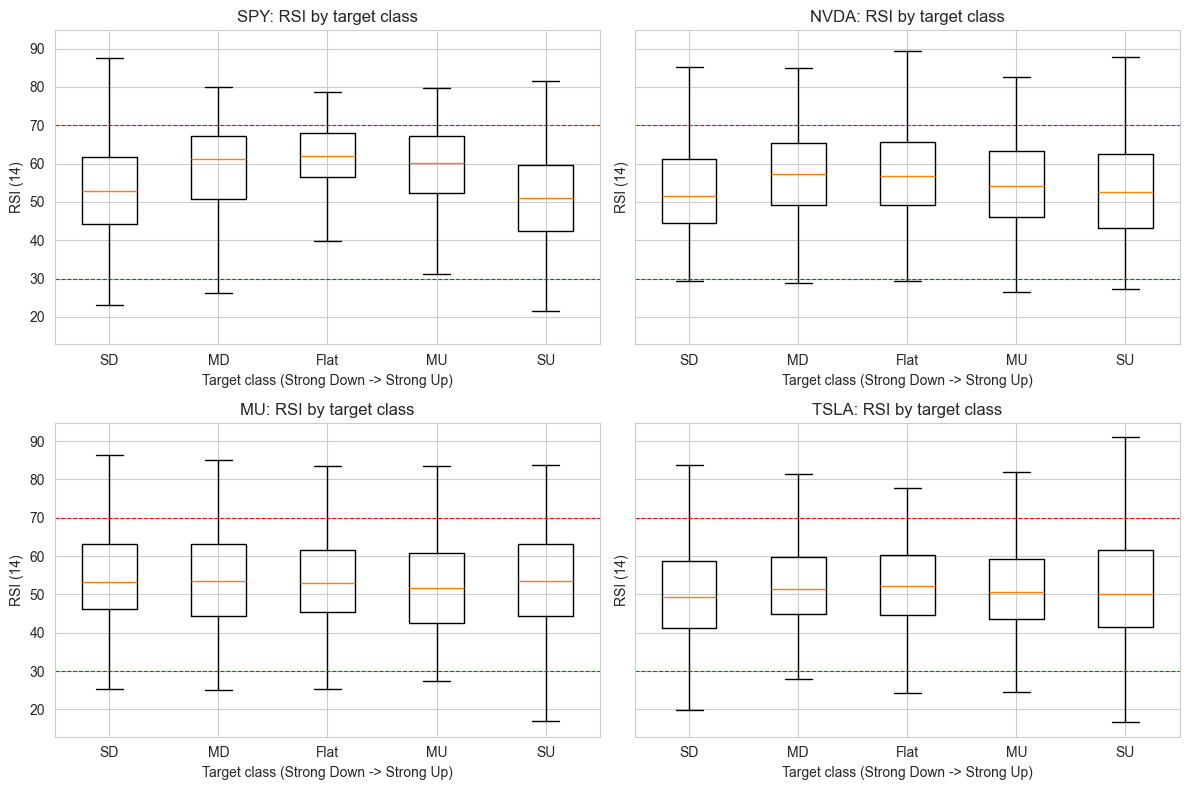

In [93]:
# 3. rsi by target class, one panel per stock
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, s in zip(axes.ravel(), SYMBOLS):
    d = feat[s][["rsi_14", "target"]].dropna()
    groups = [d.loc[d.target == c, "rsi_14"].values for c in range(5)]
    ax.boxplot(groups, labels=["SD", "MD", "Flat", "MU", "SU"], showfliers=False)
    ax.set_title(f"{s}: RSI by target class")
    ax.set_xlabel("Target class (Strong Down -> Strong Up)")
    ax.set_ylabel("RSI (14)")
    ax.axhline(70, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(30, color="green", linestyle="--", linewidth=0.8)
plt.tight_layout(); plt.show()

The RSI medians all sit around ~50 with heavily overlapping boxes. The only ones that drift a bit are SPY's middle down, flat, and middle up classes, but the overlap is big enough that it doesn't really mean anything. RSI just doesn't separate the classes, so it doesn't help much for predicting the next day's move.

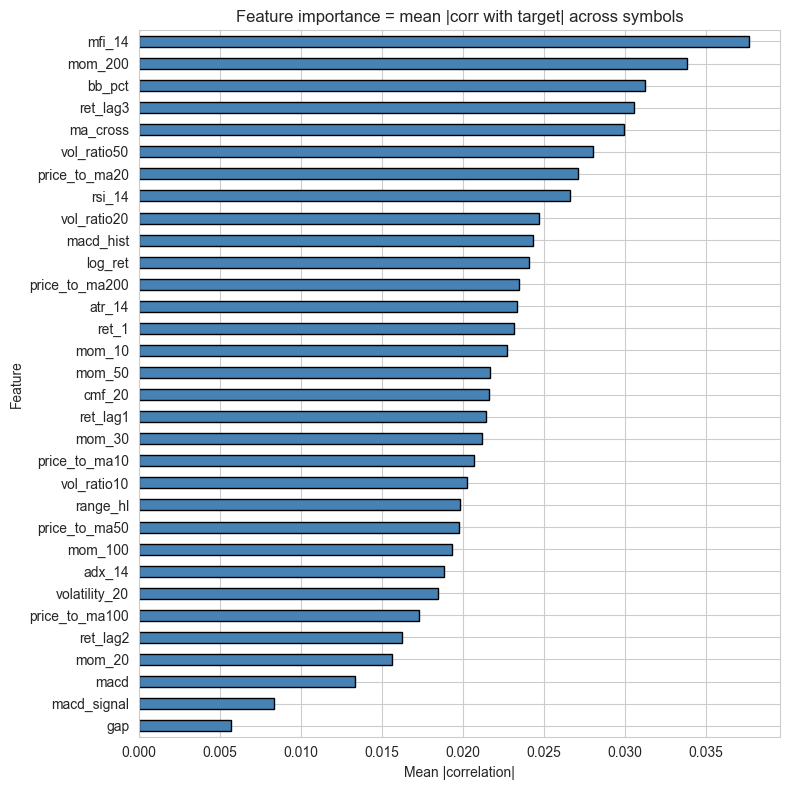

Top 5 by |corr|: ['mfi_14', 'mom_200', 'bb_pct', 'ret_lag3', 'ma_cross']


In [94]:
# 4. feature importance = mean |corr| across symbols
imp = corr_tbl.abs().mean(axis=1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
imp.plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.invert_yaxis()
ax.set_title("Feature importance = mean |corr with target| across symbols")
ax.set_xlabel("Mean |correlation|")
ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()
print("Top 5 by |corr|:", list(imp.head(5).index))

The ranking shows which feature carrys the most relative siginal but it is all very low, with the highest being slightly greater than 0.035, which is 3.5%. because of this finding, I was curious to explore the different horizons.

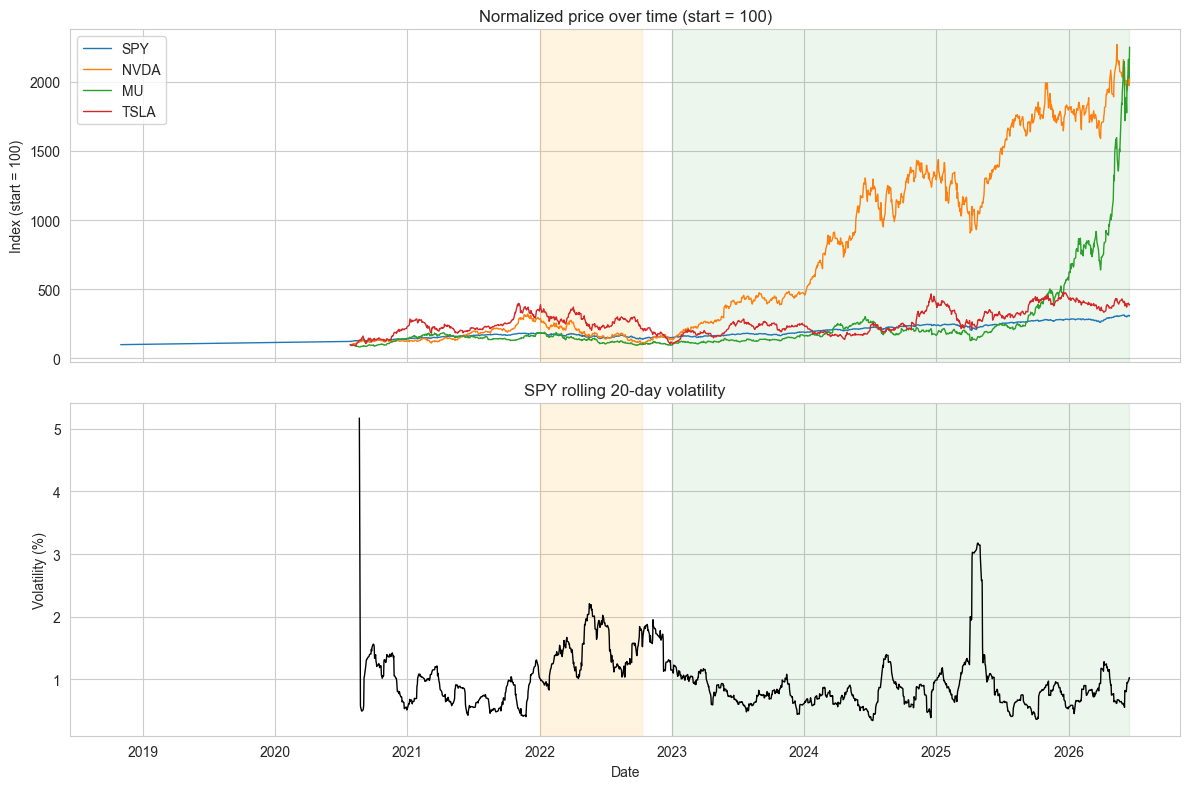

In [95]:
# 5. price + volatility over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# normalize price to start = 100
for s in SYMBOLS:
    p = raw[s]["close"]
    axes[0].plot(p.index, p / p.iloc[0] * 100, label=s, linewidth=1)
axes[0].set_title("Normalized price over time (start = 100)")
axes[0].set_ylabel("Index (start = 100)")
axes[0].legend()

# rolling 20-day volatility (SPY)
spy_vol = feat["SPY"]["ret_1"].rolling(20).std() * 100
axes[1].plot(spy_vol.index, spy_vol, color="black", linewidth=1)
axes[1].set_title("SPY rolling 20-day volatility")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volatility (%)")

# shade regimes (2022 bear, 2023+ AI boom)
for a in axes:
    a.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-12"), color="orange", alpha=0.12)
    a.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2026-06-18"), color="green",  alpha=0.07)
plt.tight_layout(); plt.show()

So this shows that NVDA really takes off after 2023 which is during the AI Boom, and that there was also a volatility spike during the 2022 bear before things settled back down. 

I think this is important to notice because the test set is the more recent market trends (which sits at a more calmer period), while the 2022 period is less stable, and is what is used in the training dataset.

We are curious about its impacts and whether or not it would lead to differences in the results, since a single split never really tests the model on a bear or a more volatiile market, and what it would look like if we staggered the data and did a rolling split across several periods to check.